In [29]:
# ============================================================
# PDF MODÜLÜ
# PyMuPDF Sürümü
# ============================================================

# ------------------------------------------------------------
# Kurulum
# ------------------------------------------------------------
!pip -q install pymupdf

# ------------------------------------------------------------
# Kütüphaneler
# ------------------------------------------------------------
from google.colab import files
import fitz
from PIL import Image
import matplotlib.pyplot as plt

# ============================================================
# TESSERACT OCR
# ============================================================

# ------------------------------------------------------------
# Tesseract kurulumu
# ------------------------------------------------------------
!apt-get -qq update
!apt-get -qq install tesseract-ocr
!apt-get -qq install tesseract-ocr-tur

!pip -q install pytesseract

# ------------------------------------------------------------
# Kütüphaneler
# ------------------------------------------------------------
import pytesseract
import re
from PIL import Image


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Lütfen PDF dosyalarını seçiniz...


Saving Scan.121959.pdf to Scan.121959.pdf
Saving Scan.122031.pdf to Scan.122031.pdf
Saving Scan.122232.pdf to Scan.122232.pdf
Saving Scan.122326.pdf to Scan.122326.pdf
Saving Scan.122421.pdf to Scan.122421.pdf
Saving Scan.122509.pdf to Scan.122509.pdf


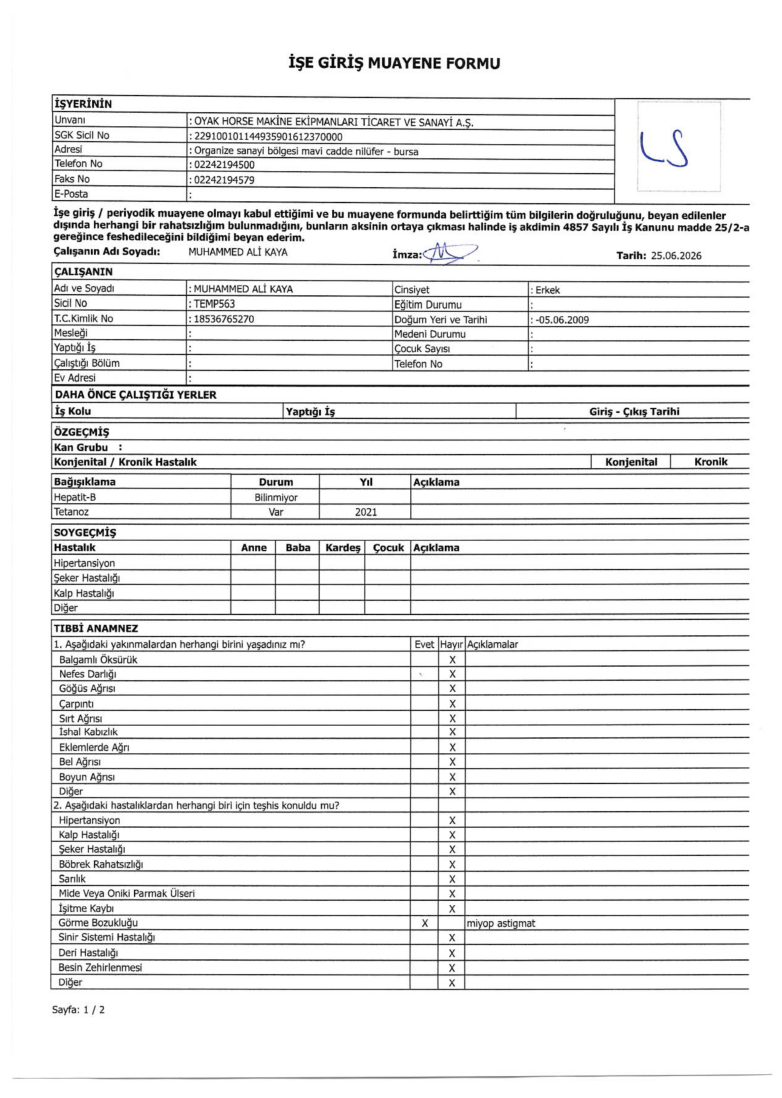

Toplam oluşturulan PNG sayısı: 6


In [30]:
# ============================================================
# PDF MODÜLÜ
# PDF → 1. SAYFA → PNG (600 DPI)
# PyMuPDF Sürümü
# ============================================================

# ------------------------------------------------------------
# PDF seç
# ------------------------------------------------------------
print("Lütfen PDF dosyalarını seçiniz...")

uploaded = files.upload()

if len(uploaded) == 0:
    raise Exception("Dosya seçilmedi.")

# ------------------------------------------------------------
# Sayfa sayacı
# ------------------------------------------------------------
sayac = 1
pdf_adlari = {}

# ------------------------------------------------------------
# Tüm PDF'leri işle
# ------------------------------------------------------------
for dosya_adi in uploaded.keys():

    if not dosya_adi.lower().endswith(".pdf"):
        raise Exception("Sadece PDF dosyası kabul edilir.")

    # ------------------------------------------------------------
    # PDF aç
    # ------------------------------------------------------------
    pdf = fitz.open(dosya_adi)

    # ------------------------------------------------------------
    # İlk sayfa
    # ------------------------------------------------------------
    sayfa = pdf.load_page(0)

    # ------------------------------------------------------------
    # 600 DPI
    # ------------------------------------------------------------
    zoom = 600 / 72
    matris = fitz.Matrix(zoom, zoom)

    pix = sayfa.get_pixmap(matrix=matris, alpha=False)

    # ------------------------------------------------------------
    # PNG olarak kaydet
    # ------------------------------------------------------------
    png_dosya = f"sayfa_{sayac}.png"
    pix.save(png_dosya)

    pdf_adlari[sayac] = dosya_adi

    sayac += 1

# ------------------------------------------------------------
# Son oluşturulan PNG'yi göster
# ------------------------------------------------------------
gorsel = Image.open(png_dosya)

plt.figure(figsize=(10,14))
plt.imshow(gorsel)
plt.axis("off")
plt.show()

print(f"Toplam oluşturulan PNG sayısı: {sayac - 1}")

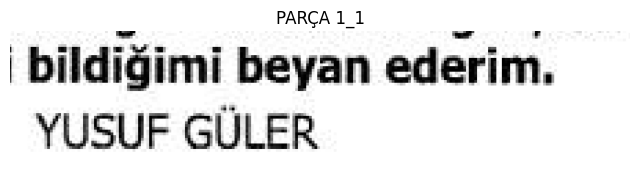

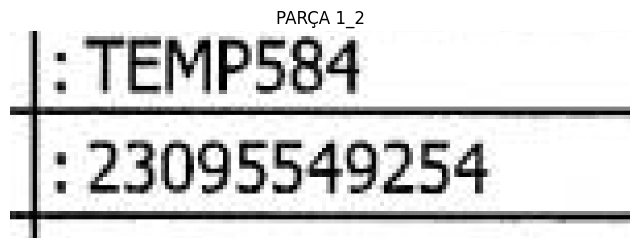

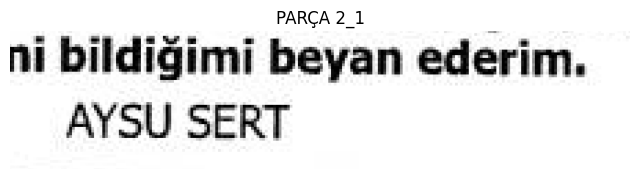

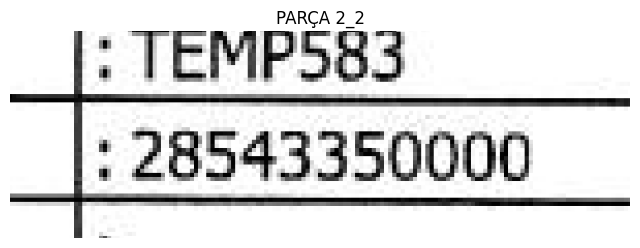

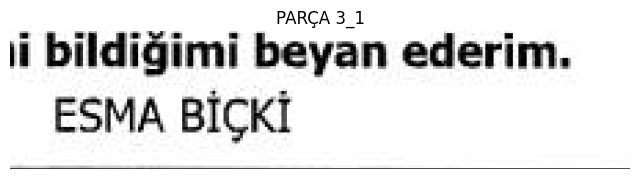

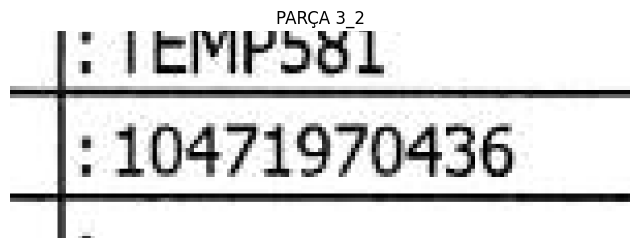

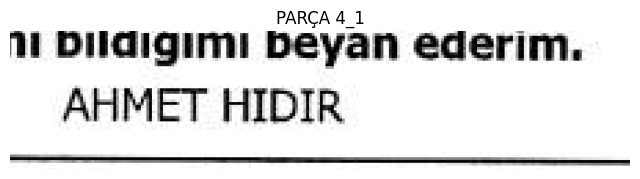

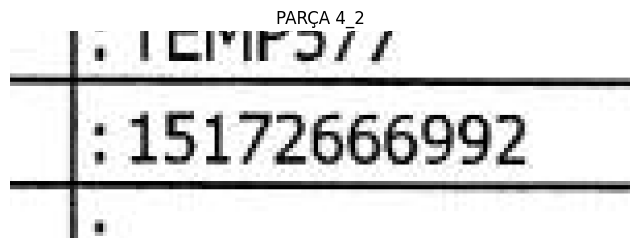

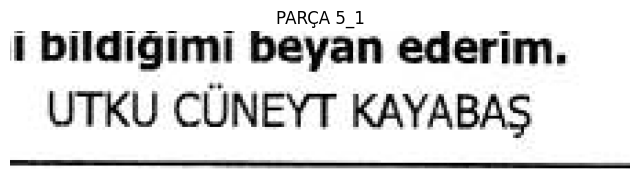

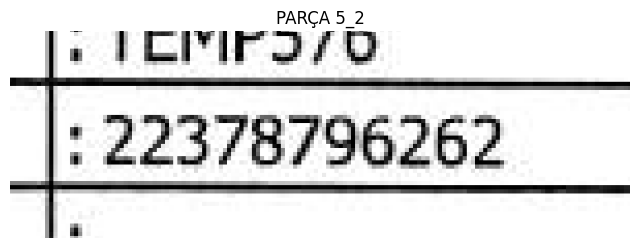

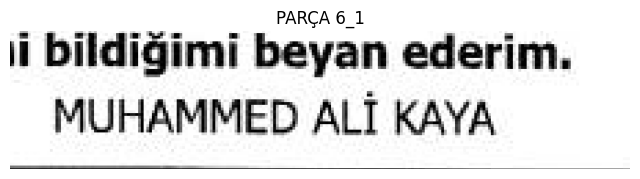

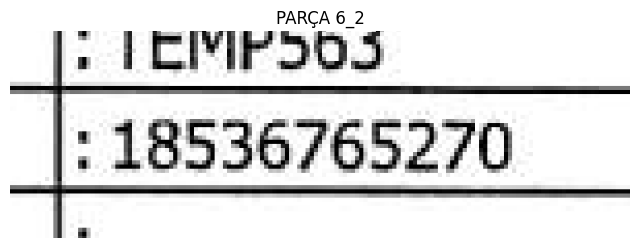

In [31]:
# ============================================================
# AŞAMA 2
# PNG'DEN İKİ BÖLGEYİ KES
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Bir önceki aşamada oluşan PNG
# ------------------------------------------------------------
for i in range(1, sayac):

    gorsel = Image.open(f"sayfa_{i}.png")

    # ------------------------------------------------------------
    # KIRPMA ALANI - 1
    # ------------------------------------------------------------
    # Sol üst köşe
    x1 = 1100
    y1 = 1450

    # Sağ alt köşe
    x2 = 2000
    y2 = 1650

    parca1 = gorsel.crop((x1, y1, x2, y2))
    parca1.save(f"parca_{i}_1.png")

    # ------------------------------------------------------------
    # KIRPMA ALANI - 2
    # ------------------------------------------------------------
    x1 = 1100
    y1 = 1900

    x2 = 1700
    y2 = 2100

    parca2 = gorsel.crop((x1, y1, x2, y2))
    parca2.save(f"parca_{i}_2.png")

# ------------------------------------------------------------
# SONUÇLARI GÖSTER
# ------------------------------------------------------------

for i in range(1, sayac):

    plt.figure(figsize=(8,4))
    plt.imshow(Image.open(f"parca_{i}_1.png"))
    plt.axis("off")
    plt.title(f"PARÇA {i}_1")
    plt.show()

    plt.figure(figsize=(8,4))
    plt.imshow(Image.open(f"parca_{i}_2.png"))
    plt.axis("off")
    plt.title(f"PARÇA {i}_2")
    plt.show()

In [32]:
# ============================================================
# PNG ÜZERİNDE TESSERACT OCR
# ============================================================

for i in range(1, sayac):

    # ------------------------------------------------------------
    # Kırpılan görüntüyü aç 1.PNG
    # ------------------------------------------------------------
    gorsel = Image.open(f"parca_{i}_1.png")

    # ------------------------------------------------------------
    # OCR çalıştır
    # Türkçe dil modeli kullanılıyor.
    # ------------------------------------------------------------
    metin = pytesseract.image_to_string(
        gorsel,
        lang="tur"
    )


    # ============================================================
    # SADECE BÜYÜK HARFLİ SATIRLARI GÖSTER
    # ============================================================
    ad_soyad = ""

    for satir in metin.splitlines():

        satir = satir.strip()

        if satir == "":
            continue

        if satir == satir.upper():
            ad_soyad = satir
            break

    print(f"ad_soyad_{i}: {ad_soyad}")

    # ------------------------------------------------------------
    # Kırpılan görüntüyü aç 2.png
    # ------------------------------------------------------------
    gorsel = Image.open(f"parca_{i}_2.png")

    # ------------------------------------------------------------
    # OCR çalıştır
    # Türkçe dil modeli kullanılıyor.
    # ------------------------------------------------------------
    metin = pytesseract.image_to_string(
        gorsel,
        lang="tur"
    )

    # ------------------------------------------------------------
    # 11 haneli sayıları bul
    # ------------------------------------------------------------
    bulunanlar = re.findall(r"\b\d{11}\b", metin)

    # ------------------------------------------------------------
    # BULUNAN 11 HANELİ SAYILAR
    # ------------------------------------------------------------
    tc_no = ""

    if bulunanlar:
        tc_no = bulunanlar[0]
    else:
        tc_no = "11 haneli sayı bulunamadı."

    print(f"tc_no_{i}: {tc_no}")

ad_soyad_1: YUSUF GÜLER
tc_no_1: 23095549254
ad_soyad_2: AYSU SERT
tc_no_2: 28943350000
ad_soyad_3: ESMA BİÇKİ
tc_no_3: 10471970436
ad_soyad_4: AHMET HIDIR
tc_no_4: 15172666992
ad_soyad_5: UTKU CÜNEYT KAYABAŞ
tc_no_5: 22378796262
ad_soyad_6: MUHAMMED ALİ KAYA
tc_no_6: 18536765270


In [33]:
# ============================================================
# EXCEL OLUŞTUR
# ============================================================

!pip -q install openpyxl

from openpyxl import Workbook
import re
from PIL import Image
import pytesseract

# Yeni Excel oluştur
wb = Workbook()
ws = wb.active

# Başlıklar
ws["A1"] = "AD SOYAD"
ws["B1"] = "TC NO"
ws["C1"] = "DOSYA ADI"
ws["D1"] = "PDF ADI"

satir_no = 2

for i in range(1, sayac):

    # AD SOYAD
    gorsel = Image.open(f"parca_{i}_1.png")
    metin = pytesseract.image_to_string(
        gorsel,
        lang="tur"
    )

    ad_soyad = ""

    for satir in metin.splitlines():

        satir = satir.strip()

        if satir == "":
            continue

        if satir == satir.upper():
            ad_soyad = satir
            break

    # TC NO
    gorsel = Image.open(f"parca_{i}_2.png")
    metin = pytesseract.image_to_string(
        gorsel,
        lang="tur"
    )

    bulunanlar = re.findall(r"\b\d{11}\b", metin)

    tc_no = ""

    if bulunanlar:
        tc_no = bulunanlar[0]
    else:
        tc_no = "11 haneli sayı bulunamadı."

    # Veriler
    ws[f"A{satir_no}"] = ad_soyad
    ws[f"B{satir_no}"] = tc_no
    ws[f"C{satir_no}"] = f"{tc_no}_{ad_soyad}_İşe Giriş"
    ws[f"D{satir_no}"] = pdf_adlari[i]

    satir_no += 1

# Kaydet
excel_adi = "Sonuc.xlsx"
wb.save(excel_adi)

print("\nExcel oluşturuldu.")
print(excel_adi)

# ============================================================
# EXCEL DOSYASINI İNDİR.
# EXCEL AÇ
# KLASÖR İÇİNDEKİ MACRO İÇEREN EXCEL DOSYASINA YAPIŞTIR
# ALT + F8 YAP ÇALIŞTIR DE DOSYA İSİMLERİ DEĞİŞİR
# ============================================================


Excel oluşturuldu.
Sonuc.xlsx


In [28]:
# ============================================================
# DOSYALARI SİL ÜRETİLEN DOSYALARI SİLER
# ============================================================
import os
import glob

uzantilar = ["*.pdf", "*.png", "*.xlsx"]

for uzanti in uzantilar:
    for dosya in glob.glob(f"/content/{uzanti}"):
        os.remove(dosya)

print("Geçici dosyalar silindi.")

Geçici dosyalar silindi.
